<a href="https://colab.research.google.com/github/ngkhanhly3103/Emotion-Recognition/blob/master/EEG_CNNBiLSTM_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import random
import os
import shutil
import zipfile
import gc
import time
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, precision_score, recall_score
import psutil
from scipy import signal
import torchaudio
import torch.nn.functional as F
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# @title
!pip install mne
import mne
emotion_channels = [
        #Frontal
        'AF3', 'AF4', 'F3', 'F4',
        'F7', 'F8','FC5', 'FC6',
        #Temporal
        'T7', 'T8',
        #Parietal
        'P7', 'P8',
        #Occipital
        'O1', 'O2']

# Load 1 file raw bất kỳ để lấy danh sách tên kênh của AFFEC
# (Thay đường dẫn tới 1 file .fif bất kỳ trên Drive của bạn)
SAMPLE_FILE = '/content/drive/MyDrive/AFFEC/preprocessed_eeg/sub-acl_task-fer_run-1_eeg_clean_raw.fif'
raw = mne.io.read_raw_fif(SAMPLE_FILE, preload=False, verbose=False)
all_channels = raw.ch_names

# Tìm index
indices = [all_channels.index(ch) for ch in emotion_channels if ch in all_channels]

print(f"✅ TÌM THẤY {len(indices)}/14 KÊNH:")
print(f"Indices = {indices}")

✅ TÌM THẤY 14/14 KÊNH:
Indices = [4, 5, 9, 13, 7, 15, 17, 23, 25, 33, 43, 51, 57, 59]


In [ ]:
CONFIG = {
    'drive_zip_path': '/content/drive/MyDrive/AFFEC/eeg_segment_new.zip',
    'data_dir': Path('/content/drive/MyDrive/AFFEC/EEG results'),
    'local_data_dir': Path('/content/temp_data'),
    'common_subjects_file': '/content/drive/MyDrive/AFFEC/late_fusion_results/common_subjects.txt',
    'batch_size': 64,
    'learning_rate': 1e-3,
    'epochs': 80,
    'num_workers': 0,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'num_classes': 4,
    'emotion_labels': ['HAHV', 'HALV', 'LAHV', 'LALV'],
    'patience': 15,
    'expected_shape': (63, 256),
    'output_dir': Path('/content/drive/MyDrive/AFFEC'),
    'sampling_rate': 128,
}

channel_indices = indices
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

In [ ]:
# Đường dẫn thư mục giải nén
local_data_dir = Path('/content/temp_data')

print(f"🔍 Đang kiểm tra dữ liệu tại: {local_data_dir}")

# Lấy 1 file mẫu bất kỳ
sample_files = list(local_data_dir.rglob('*_X.npy'))

if len(sample_files) == 0:
    print("❌ THẢM HỌA: Thư mục này RỖNG! (Chưa giải nén hoặc giải nén sai chỗ)")
else:
    print(f"✅ Tìm thấy {len(sample_files)} file .npy")

    # Kiểm tra 5 file đầu tiên
    print("\n--- KIỂM TRA 5 FILE ĐẦU TIÊN ---")
    for i, f in enumerate(sample_files[:5]):
        try:
            x = np.load(f)
            print(f"File {i+1}: {f.name}")
            print(f"   👉 Shape thực tế: {x.shape}")
            print(f"   👉 Kiểu dữ liệu: {x.dtype}")
        except Exception as e:
            print(f"   ❌ Lỗi đọc file: {e}")

    print("-" * 30)
    print("💡 HÃY SO SÁNH 'Shape thực tế' Ở TRÊN VỚI CONFIG CỦA BẠN!")

🔍 Đang kiểm tra dữ liệu tại: /content/temp_data
✅ Tìm thấy 268 file .npy

--- KIỂM TRA 5 FILE ĐẦU TIÊN ---
File 1: sub-blgv_run-3_X.npy
   👉 Shape thực tế: (509, 63, 256)
   👉 Kiểu dữ liệu: float64
File 2: sub-blgv_run-0_X.npy
   👉 Shape thực tế: (112, 63, 256)
   👉 Kiểu dữ liệu: float64
File 3: sub-blgv_run-2_X.npy
   👉 Shape thực tế: (647, 63, 256)
   👉 Kiểu dữ liệu: float64
File 4: sub-blgv_run-1_X.npy
   👉 Shape thực tế: (648, 63, 256)
   👉 Kiểu dữ liệu: float64
File 5: sub-zig_run-3_X.npy
   👉 Shape thực tế: (415, 63, 256)
   👉 Kiểu dữ liệu: float64
------------------------------
💡 HÃY SO SÁNH 'Shape thực tế' Ở TRÊN VỚI CONFIG CỦA BẠN!


In [ ]:
def print_ram_usage():
    process = psutil.Process(os.getpid())
    print(f"RAM: {process.memory_info().rss / 1024 ** 3:.2f} GB")

def load_data():
    """
    Load dữ liệu EEG:
    - Test: Lấy từ file common_subjects.txt (để dành cho Fusion).
    - Train/Val: Lấy từ tất cả các subject còn lại.
    """
    print(f"\n{'='*60}")
    print(f"LOADING DATA")
    print(f"{'='*60}")

    local_dir = CONFIG['local_data_dir']
    zip_path = CONFIG['drive_zip_path']
    txt_path = CONFIG.get('common_subjects_file', '/content/drive/MyDrive/AFFEC/late_fusion_results/common_subjects.txt')

    # 1. Giải nén (nếu chưa có)
    if not local_dir.exists():
        print("Đang giải nén dữ liệu...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(local_dir)
        print("Giải nén xong.")

    print_ram_usage()

    # 2. Đọc danh sách Common Subjects (để chốt Test Set)
    if not os.path.exists(txt_path):
        print(f"Cảnh báo: Không tìm thấy {txt_path}. Sẽ dùng chia ngẫu nhiên!")
        fixed_test_subjects = []
    else:
        with open(txt_path, 'r') as f:
            common_users = [line.strip() for line in f.readlines() if line.strip()]
        common_users.sort()

    n_test_count = 10

    fixed_test_subjects = common_users[-n_test_count:]

    print(f"Tìm thấy {len(common_users)} user chung.")
    print(f"Test set ({len(fixed_test_subjects)} users): {fixed_test_subjects}")

    # 3. Quét toàn bộ file EEG
    print("Đang quét file .npy...")
    x_files = sorted(list(local_dir.rglob('*_X.npy')))

    # Phân loại file vào các bucket
    train_files, val_files, test_files = [], [], []

    # Lấy danh sách tất cả subject có trong folder EEG
    all_subjects = set()
    for f in x_files:
        raw_name = f.name.split('_')[0] # 'sub-zry'
        all_subjects.add(raw_name)

    # Xác định danh sách Train/Val từ những người KHÔNG phải Test
    remaining_subjects = list(all_subjects - set(fixed_test_subjects))
    remaining_subjects.sort()

    # Chia Train/Val từ danh sách còn lại (85/15)
    train_subs, val_subs = train_test_split(remaining_subjects, test_size=0.15, random_state=42)

    print(f"\nPHÂN BỐ SUBJECTS:")
    print(f"   - Test: {len(fixed_test_subjects)}")
    print(f"   - Train (Bao gồm cả người không có FAU): {len(train_subs)}")
    print(f"   - Val: {len(val_subs)}")

    # 4. Hàm load data nội bộ (Tối ưu hóa để chạy 1 vòng lặp)
    X_train, y_train = [], []
    X_val, y_val = [], []
    X_test, y_test = [], []

    print("\nĐang load dữ liệu vào RAM...")

    for i, x_file in enumerate(x_files):
        try:
            # Lấy tên subject
            subject = x_file.name.split('_')[0]

            # Load X
            x = np.load(x_file)

            # Validate Shape (N, 63, 256)
            if x.ndim == 3 and x.shape[1:] == (63, 256):
                # Chọn kênh (Feature Selection)
                if len(indices) > 0:
                    x = x[:, indices, :] # (N, 14, 256)

                # Load Y
                y_file = x_file.parent / x_file.name.replace('_X.npy', '_y.npy')
                if not y_file.exists(): continue
                y = np.load(y_file)

                # Fix shape Y
                if y.ndim == 0: y = np.full(x.shape[0], y)
                elif y.ndim == 1 and len(y) != x.shape[0]: continue

                # Ép kiểu
                x = x.astype(np.float32)
                y = y.astype(np.int64)

                # Phân loại vào List tương ứng
                if subject in fixed_test_subjects:
                    X_test.append(x); y_test.append(y)
                elif subject in val_subs:
                    X_val.append(x); y_val.append(y)
                elif subject in train_subs:
                    X_train.append(x); y_train.append(y)

        except Exception as e:
            print(f"Lỗi file {x_file.name}: {e}")
            continue

    # Helper gộp mảng
    def concat_data(x_list, y_list):
        if not x_list: return np.array([]), np.array([])
        return np.concatenate(x_list, axis=0), np.concatenate(y_list, axis=0)

    X_train, y_train = concat_data(X_train, y_train)
    X_val, y_val = concat_data(X_val, y_val)
    X_test, y_test = concat_data(X_test, y_test)

    print(f"\nKẾT QUẢ LOAD DATA:")
    print(f"   Train samples: {len(y_train)}")
    print(f"   Val samples:   {len(y_val)}")
    print(f"   Test samples:  {len(y_test)}")

    gc.collect()
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

In [ ]:
from collections import Counter
def balance_downsample_majority(X, y):
    """
    Chỉ cắt bớt các class có số lượng quá cao xuống mức trung bình.
    Giữ nguyên toàn bộ các class ít.
    """
    if len(X) == 0: return X, y

    # Chuyển sang numpy để xử lý
    X_np = X if isinstance(X, np.ndarray) else X.numpy()
    y_np = y if isinstance(y, np.ndarray) else y.numpy()

    counts = Counter(y_np)

    # Tính ngưỡng trần (Limit) = Trung bình cộng số lượng các class
    # Ví dụ: Nếu có [30k, 10k, 10k, 10k] -> Avg = 15k -> Class 30k sẽ bị cắt xuống 15k
    avg_count = int(np.mean(list(counts.values())))

    # Nếu muốn giữ lại nhiều hơn một chút (ví dụ 1.2 lần trung bình), nhân thêm hệ số vào avg_count
    limit = int(avg_count * 1.1)

    target_counts = {k: min(v, limit) for k, v in counts.items()}

    print(f"  Original counts: {dict(counts)}")
    print(f"  Cut-off Limit : {limit}")
    print(f"  Target counts  : {target_counts}")

    balanced_X = []
    balanced_y = []

    for class_label in range(4): # 4 class cảm xúc
        mask = (y_np == class_label)
        class_X = X_np[mask]
        class_y = y_np[mask]

        target = target_counts[class_label]

        # Nếu số lượng hiện tại lớn hơn target -> Random Choice để cắt bớt
        if len(class_X) > target:
            # Chọn ngẫu nhiên không hoàn lại (replace=False) để lấy đúng số lượng target
            indices = np.random.choice(len(class_X), size=target, replace=False)
            balanced_X.append(class_X[indices])
            balanced_y.append(class_y[indices])
        else:
            # Nếu nhỏ hơn hoặc bằng -> Giữ nguyên toàn bộ (KHÔNG nhân bản)
            balanced_X.append(class_X)
            balanced_y.append(class_y)

    # Gộp lại
    if balanced_X:
        balanced_X = np.concatenate(balanced_X, axis=0)
        balanced_y = np.concatenate(balanced_y, axis=0)

        print(f" Final Size: {len(y)} -> {len(balanced_y)} samples")
        return torch.from_numpy(balanced_X).float(), torch.from_numpy(balanced_y).long()
    else:
        return torch.from_numpy(X_np).float(), torch.from_numpy(y_np).long()

def print_label_counts(y, set_name="Data"):
    if isinstance(y, torch.Tensor): y = y.cpu().numpy()
    unique, counts = np.unique(y, return_counts=True)
    print(f"{set_name}: {dict(zip(unique, counts))}")

In [ ]:
class STFT_CRNN(nn.Module):
    def __init__(self, nb_classes=4, Chans=14, dropout_rate=0.25):
        super().__init__()

        # --- LAYER 1: STFT TRANSFORMATION  ---
        # Input: (Batch, 14, 256)
        # Output: (Batch, 14, Freq=33, Time=17)
        self.stft = torchaudio.transforms.Spectrogram(
            n_fft=64,       # Cửa sổ nhỏ (0.5s) để bắt tần số nhanh
            hop_length=16,  # Bước nhảy nhỏ để tạo chuỗi thời gian dài (17 bước)
            power=2.0,      # Power spectrum
            normalized=True
        )

        # Chuẩn hóa năng lượng đầu vào
        self.instance_norm = nn.InstanceNorm2d(Chans)

        # --- LAYER 2: CNN ENCODER (Xử lý ảnh Spectrogram) ---
        self.cnn = nn.Sequential(
            # Block 1
            nn.Conv2d(Chans, 16, kernel_size=(3, 1), padding=(1, 0)),
            nn.BatchNorm2d(16), nn.ELU(), nn.Dropout(dropout_rate),
            nn.MaxPool2d((2, 1)), # Chỉ giảm chiều Tần số (33->16), GIỮ NGUYÊN Thời gian

            # Block 2
            nn.Conv2d(16, 32, kernel_size=(3, 1), padding=(1, 0)),
            nn.BatchNorm2d(32), nn.ELU(), nn.Dropout(dropout_rate),
            nn.MaxPool2d((2, 1))  # (16->8)
        )

        # Sau CNN: (Batch, 32, Freq=8, Time=17)
        # Ta cần: (Batch, Time=17, Features)
        # Features = Channels(32) * Freq(8) = 256
        self.lstm_input_size = 256
        self.hidden_size = 64

        # --- LAYER 3: BiLSTM ---
        self.bilstm = nn.LSTM(
            input_size=self.lstm_input_size,
            hidden_size=self.hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # ---  LAYER 4: ATTENTION MECHANISM ---
        # Mạng nơ-ron nhỏ để tính điểm quan trọng (Attention Score)
        # Input: (Batch, Time, Hidden*2) -> Output: (Batch, Time, 1)
        self.attention_weights = nn.Sequential(
            nn.Linear(self.hidden_size * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        # --- LAYER 5: CLASSIFIER ---
        self.classifier = nn.Sequential(
            nn.Linear(self.hidden_size * 2, 32),
            nn.ELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, nb_classes)
        )

    def forward(self, x):
        # 1. Tự động tính Spectrogram trên GPU
        x = self.stft(x)            # (B, 14, 33, 17)
        x = torch.log(x + 1e-6)     # Chuyển sang dB (Log Transform) - Bắt buộc
        x = self.instance_norm(x)   # Chuẩn hóa Z-score

        # 2. CNN Feature Extraction
        x = self.cnn(x)             # (B, 64, 8, 17)

        # 3. Reshape: Đưa Time ra giữa để vào LSTM
        x = x.permute(0, 3, 1, 2)   # (B, 17, 64, 8)
        B, T, C, FREQ = x.shape
        x = x.reshape(B, T, C*FREQ)    # (B, 17, 512)

        # 4. LSTM
        lstm_out, _ = self.bilstm(x)# (B, 17, 256)

        # 5. ATTENTION CALCULATION
        # A. Tính điểm năng lượng (Score) cho từng bước thời gian
        # (B, 17, 128) -> (B, 17, 1)
        attn_scores = self.attention_weights(lstm_out)

        # B. Tính trọng số (Weights) bằng Softmax trên trục thời gian (dim=1)
        # Những đoạn quan trọng sẽ có weight cao, nhiễu sẽ có weight thấp
        attn_weights = F.softmax(attn_scores, dim=1)

        # C. Tính Context Vector (Tổng có trọng số)
        # Nhân từng bước thời gian với trọng số của nó rồi cộng lại
        # (B, 17, 128) * (B, 17, 1) -> sum(dim=1) -> (B, 128)
        context_vector = torch.sum(lstm_out * attn_weights, dim=1)

        return self.classifier(context_vector)

# Khởi tạo thử để kiểm tra
model = STFT_CRNN(nb_classes=4, Chans=14).to(CONFIG['device'])
print(f"Total Params: {sum(p.numel() for p in model.parameters()):,}")

Total Params: 179,797


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


In [ ]:
!pip install torchinfo
from torchinfo import summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = STFT_CRNN(nb_classes=4, Chans=14).to(CONFIG['device'])
summary(model, input_size=(64, 14, 256))

Layer (type:depth-idx)                   Output Shape              Param #
STFT_CRNN                                [64, 4]                   --
├─Spectrogram: 1-1                       [64, 14, 33, 17]          --
├─InstanceNorm2d: 1-2                    [64, 14, 33, 17]          --
├─Sequential: 1-3                        [64, 32, 8, 17]           --
│    └─Conv2d: 2-1                       [64, 16, 33, 17]          688
│    └─BatchNorm2d: 2-2                  [64, 16, 33, 17]          32
│    └─ELU: 2-3                          [64, 16, 33, 17]          --
│    └─Dropout: 2-4                      [64, 16, 33, 17]          --
│    └─MaxPool2d: 2-5                    [64, 16, 16, 17]          --
│    └─Conv2d: 2-6                       [64, 32, 16, 17]          1,568
│    └─BatchNorm2d: 2-7                  [64, 32, 16, 17]          64
│    └─ELU: 2-8                          [64, 32, 16, 17]          --
│    └─Dropout: 2-9                      [64, 32, 16, 17]          --
│    └─MaxP

In [ ]:
# @title
# ============================================================================
# EARLY STOPPING
# ============================================================================
class EarlyStopping:
    def __init__(self, patience=CONFIG['patience'], min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_score):
        if self.best_score is None:
            self.best_score = val_score
        elif val_score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_score
            self.counter = 0

In [ ]:
def print_label_counts(y, set_name="Data"):
    """
    In ra số lượng và tỉ lệ phần trăm của từng nhãn
    y: Numpy array hoặc Tensor chứa nhãn
    """
    # Chuyển về numpy nếu là tensor
    if isinstance(y, torch.Tensor):
        y = y.cpu().numpy()

    unique, counts = np.unique(y, return_counts=True)
    total = len(y)

    print(f"\n{set_name} Distribution (Total: {total}):")
    print("-" * 40)
    print(f"{'LabelID':<8} | {'Emotion':<10} | {'Count':<8} | {'Percent'}")
    print("-" * 40)

    for i, count in zip(unique, counts):
        label_id = int(i)
        label_name = CONFIG['emotion_labels'][label_id]
        percent = (count / total) * 100
        print(f"{label_id:<8} | {label_name:<10} | {count:<8} | {percent:.2f}%")
    print("-" * 40)

In [ ]:
def train_model():
    # 1. Load Data
    (X_tr, y_tr), (X_val, y_val), (X_te, y_te) = load_data()
    if len(X_tr) == 0: return

    # KIỂM TRA SỐ LƯỢNG NHÃN TRƯỚC KHI CÂN BẰNG
    print("\nKIỂM TRA PHÂN BỐ NHÃN GỐC:")
    print_label_counts(y_tr, "Train")
    print_label_counts(y_val, "Val")
    print_label_counts(y_te, "Test")

    # 2. Balance & Tensor
    #print("Balancing Data...")
    #X_tr, y_tr = balance_downsample_majority(X_tr, y_tr)

    #print("Data aftere balancing:")
    #print_label_counts(y_tr, "Train (Balanced)")

    train_ds = TensorDataset(torch.tensor(X_tr).float(), torch.tensor(y_tr).long())
    val_ds = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
    test_ds = TensorDataset(torch.tensor(X_te).float(), torch.tensor(y_te).long())

    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size']*2)
    test_loader = DataLoader(test_ds,batch_size=CONFIG['batch_size']*2)

    # 3. Model
    print(f"Initializing STFT-CNN_BiLSTM on {CONFIG['device']}")
    model = STFT_CRNN(nb_classes=4, Chans=14).to(CONFIG['device'])
    print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

    if isinstance(y_tr, torch.Tensor):
        y_train_np = y_tr.cpu().numpy()
    else:
        y_train_np = np.array(y_tr)

    all_classes = np.arange(CONFIG['num_classes'])
    # Weights & Optimizer
    class_weights = compute_class_weight(class_weight='balanced', classes=all_classes, y=y_train_np)
    print(f"Class Weights: {class_weights}")

    # 2. Chuyển thành Tensor để đưa vào Loss
    weights = torch.tensor(class_weights, dtype=torch.float32).to(CONFIG['device'])
    criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=1e-2)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

    # 4. Loop
    best_f1 = 0
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'val_f1': [], 'train_f1': [],
        'lr': []
    }

    print("\nSTART TRAINING...")
    for epoch in range(CONFIG['epochs']):
        # --- TRAIN ---
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        train_preds, train_targets = [], []

        for X, y in train_loader:
            X, y = X.to(CONFIG['device']), y.to(CONFIG['device'])

            optimizer.zero_grad()
            out = model(X) # X là Raw data, Model tự tính STFT
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            # Tính Accuracy ngay trong vòng lặp
            preds = out.argmax(1)
            train_correct += (preds == y).sum().item()
            train_total += y.size(0)
            train_loss += loss.item()

            train_preds.extend(preds.cpu().numpy())
            train_targets.extend(y.cpu().numpy())

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = train_correct / train_total
        train_f1 = f1_score(train_targets, train_preds, average='macro')
        # --- EVAL ---
        model.eval()
        val_loss = 0
        preds_list, targets_list = [], []

        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(CONFIG['device']), y.to(CONFIG['device'])
                out = model(X)
                loss = criterion(out, y) # Tính val_loss
                val_loss += loss.item()

                preds_list.extend(out.argmax(1).cpu().numpy())
                targets_list.extend(y.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_acc = np.mean(np.array(preds_list) == np.array(targets_list))
        val_f1 = f1_score(targets_list, preds_list, average='macro')

        scheduler.step(val_f1)

        # In kết quả đã sửa lỗi format
        print(f"Epoch {epoch+1:2d} | Train Acc: {avg_train_acc:.4f} | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.4f} | Val Loss: {avg_val_loss:.4f} | F1: {val_f1:.4f} | LR: {optimizer.param_groups[0]['lr']:.5f}")

        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['train_f1'].append(train_f1)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), CONFIG['output_dir'] / 'Best_STFT_Model_fusion_new_independent_attn.pth')
            print(f"  Saved Best F1: {best_f1:.4f}")

    # --- TEST ---
    print("\nTEST EVALUATION")
    model.load_state_dict(torch.load(CONFIG['output_dir'] / 'Best_STFT_Model_fusion_new_independent_attn.pth', weights_only=True))
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(CONFIG['device'])
            out = model(X)
            preds.extend(out.argmax(1).cpu().numpy())
            targets.extend(y.numpy())

    print(classification_report(targets, preds, target_names=CONFIG['emotion_labels'], digits=4))

    cm = confusion_matrix(targets, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=CONFIG['emotion_labels'],
                yticklabels=CONFIG['emotion_labels'],
                annot_kws={"size": 14})
    plt.title(f'Confusion Matrix - Subject-Independent Split (Best F1: {best_f1:.4f})', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(CONFIG['output_dir'] / 'final_confusion_matri_sub_fusion_new_attn.png')

    # Plot History
    plt.figure(figsize=(18, 5))

    # 1. Loss
    plt.subplot(1, 3, 1)
    plt.plot(history['train_loss'], label='Train Loss', linestyle='--')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, alpha=0.3)

    # 2. Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(history['train_acc'], label='Train Acc', linestyle='--')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.title('Training and Validation Accuracy (Subject-Independent Split)')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True, alpha=0.3)

    # 3. F1 Score
    plt.subplot(1, 3, 3)
    plt.plot(history['train_f1'], label='Train F1', linestyle='--', linewidth=2)
    plt.plot(history['val_f1'], label='Val F1', linewidth=2)
    plt.title('Training & Validation F1-Score (Macro) (Subject-Independent Split)')
    plt.xlabel('Epoch'); plt.ylabel('F1 Score'); plt.legend(); plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(CONFIG['output_dir'] / 'training_history_full_metrics_sub_fusion_new_attn.png')
    plt.show()


LOADING DATA
RAM: 2.82 GB
Tìm thấy 67 user chung.
Test set (10 users): ['sub-uwdm', 'sub-xx2', 'sub-xzc', 'sub-yarq', 'sub-yel', 'sub-ymjj', 'sub-ywh', 'sub-zig', 'sub-ziym', 'sub-zry']
Đang quét file .npy...

PHÂN BỐ SUBJECTS:
   - Test: 10
   - Train (Bao gồm cả người không có FAU): 52
   - Val: 10

Đang load dữ liệu vào RAM...

KẾT QUẢ LOAD DATA:
   Train samples: 75211
   Val samples:   14561
   Test samples:  15475

KIỂM TRA PHÂN BỐ NHÃN GỐC:

Train Distribution (Total: 75211):
----------------------------------------
LabelID  | Emotion    | Count    | Percent
----------------------------------------
0        | HAHV       | 13097    | 17.41%
1        | HALV       | 23063    | 30.66%
2        | LAHV       | 20945    | 27.85%
3        | LALV       | 18106    | 24.07%
----------------------------------------

Val Distribution (Total: 14561):
----------------------------------------
LabelID  | Emotion    | Count    | Percent
----------------------------------------
0        | HAHV   

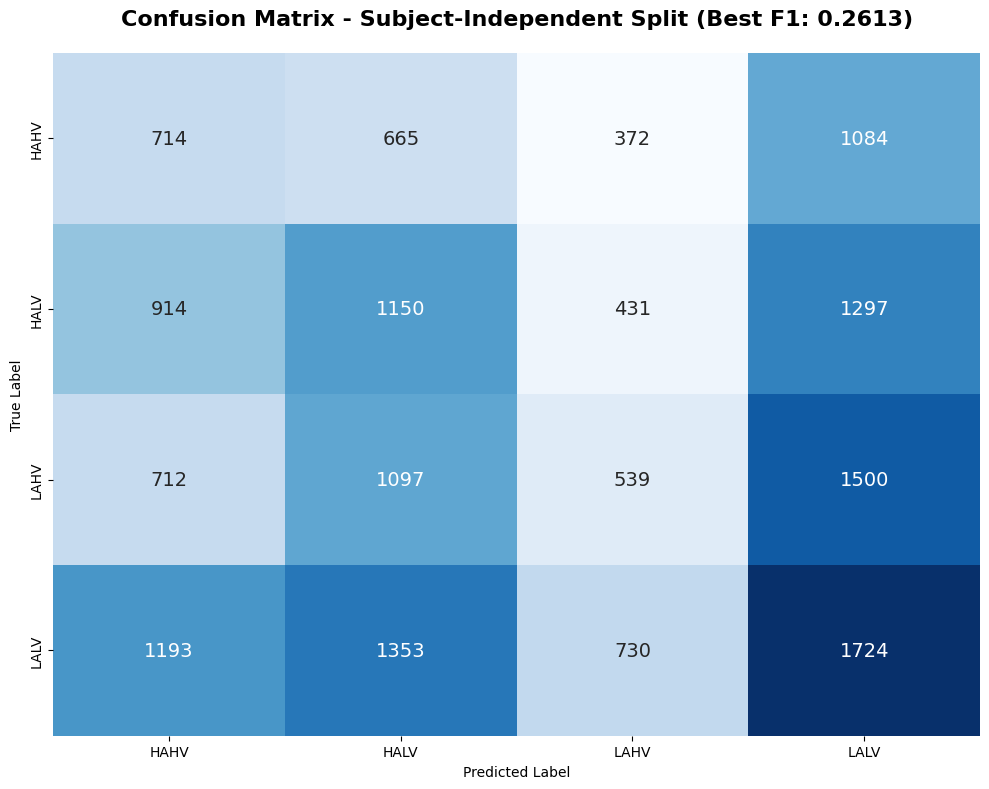

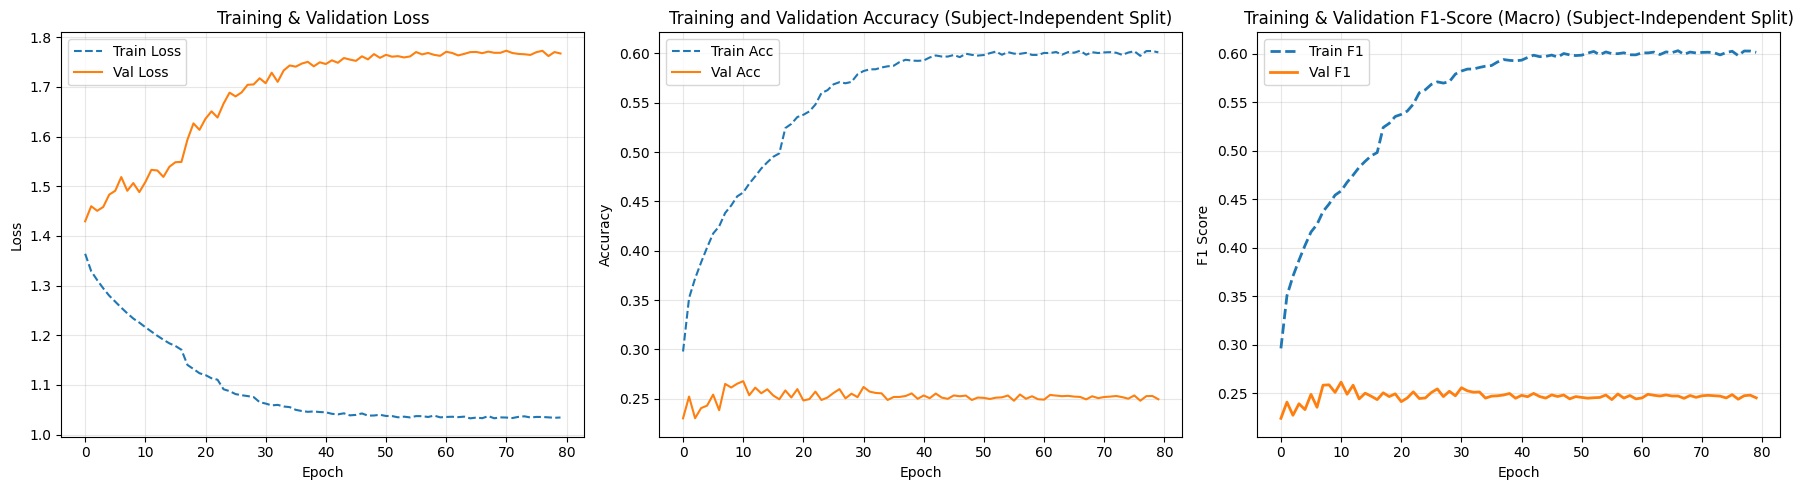

In [ ]:
if __name__ == "__main__":
    gc.collect()
    torch.cuda.empty_cache()
    train_model()
